<a href="https://colab.research.google.com/github/tevfikaytekin/CMP2003/blob/main/complexity_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sorting Algorithm Benchmark: Insertion Sort vs. Quick Sort

This notebook provides a practical performance comparison between two fundamental sorting algorithms: **Insertion Sort** ($O(n^2)$ average/worst-case complexity) and **Quick Sort** ($O(n \log n)$ average-case complexity).

### Objectives:
1. **Implement** both sorting algorithms in efficient C++ code.
2. **Benchmark** their execution times across various input sizes ($n = 1,000$ to $50,000$ random elements).
3. **Visualize** the empirical growth rates using Python and `matplotlib` to demonstrate the stark contrast between quadratic and linearithmic time complexities in practice.

In [ ]:
%%writefile sort_compare.cpp

#include <iostream>
#include <vector>
#include <chrono>
#include <cstdlib>
#include <ctime>

using namespace std;
using namespace std::chrono;

// Insertion Sort implementation
void insertionSort(vector<int>& arr) {
    int n = arr.size();
    for (int i = 1; i < n; i++) {
        int key = arr[i];
        int j = i - 1;
        while (j >= 0 && arr[j] > key) {
            arr[j + 1] = arr[j];
            j = j - 1;
        }
        arr[j + 1] = key;
    }
}

// Quick Sort partition step
int partition(vector<int>& arr, int low, int high) {
    int pivot = arr[high];
    int i = (low - 1);
    for (int j = low; j <= high - 1; j++) {
        if (arr[j] < pivot) {
            i++;
            swap(arr[i], arr[j]);
        }
    }
    swap(arr[i + 1], arr[high]);
    return (i + 1);
}

// Quick Sort implementation
void quickSort(vector<int>& arr, int low, int high) {
    if (low < high) {
        int pi = partition(arr, low, high);
        quickSort(arr, low, pi - 1);
        quickSort(arr, pi + 1, high);
    }
}

int main() {
    // Different input sizes to test
    vector<int> sizes = {1000, 5000, 10000, 20000, 30000, 40000, 50000};
    srand(time(0));

    // Print CSV header
    cout << "Size,InsertionSort,QuickSort" << endl;

    for (int n : sizes) {
        vector<int> arr1(n);
        vector<int> arr2(n);
        for (int i = 0; i < n; i++) {
            int val = rand() % 100000; // random number between 0 and 99999
            arr1[i] = val;
            arr2[i] = val; // Ensure both algorithms sort the exact same array
        }

        // Measure Insertion Sort time
        auto start1 = high_resolution_clock::now();
        insertionSort(arr1);
        auto stop1 = high_resolution_clock::now();
        auto duration1 = duration_cast<microseconds>(stop1 - start1);

        // Measure Quick Sort time
        auto start2 = high_resolution_clock::now();
        quickSort(arr2, 0, n - 1);
        auto stop2 = high_resolution_clock::now();
        auto duration2 = duration_cast<microseconds>(stop2 - start2);

        // Output the results in CSV format
        cout << n << "," << duration1.count() << "," << duration2.count() << endl;
    }

    return 0;
}

Writing sort_compare.cpp


In [ ]:
# Compile the C++ program and execute it, redirecting the output to a CSV file
!g++ -O3 -o sort_compare sort_compare.cpp
!./sort_compare > results.csv
print("C++ code executed successfully and results saved to results.csv")

C++ code executed successfully and results saved to results.csv


### Why use the `-O3` flag?
The `-O3` flag is not strictly required to make the code run, but it is highly recommended when comparing algorithm performance.

* **Maximum Optimization:** `-O3` turns on the highest level of speed optimization in the `g++` compiler. It tells the compiler to aggressively optimize loops, memory access, and function calls to make the resulting program run as fast as possible.
* **Realistic Benchmarking:** If we omit it, the compiler builds the code in unoptimized mode. The execution times would be significantly slower overall, and the overhead of the unoptimized instructions might slightly distort the pure algorithmic differences between Quick Sort and Insertion Sort.

While you can compile perfectly fine without it (e.g., `!g++ -o sort_compare sort_compare.cpp`), using `-O3` gives us a much more accurate representation of how these algorithms would perform in a real-world, production environment.

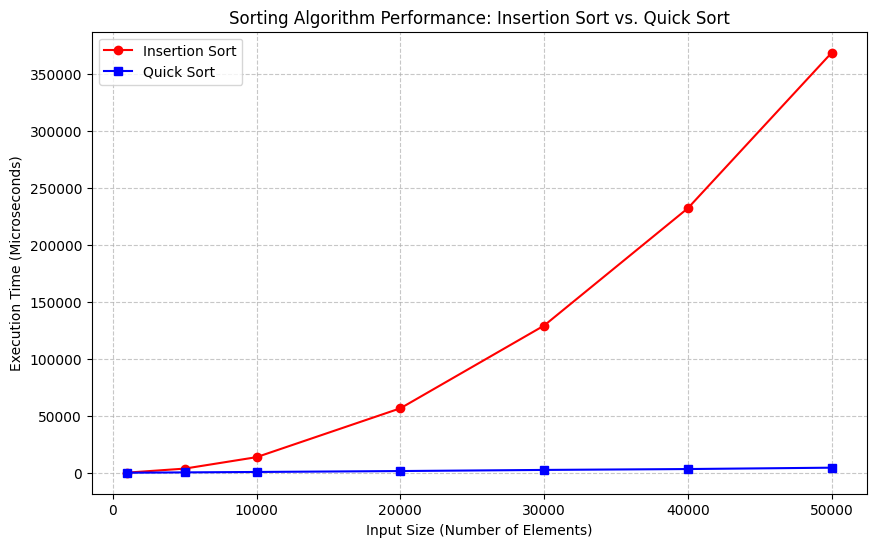

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the timing data generated by the C++ code
df = pd.read_csv('results.csv')

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(df['Size'], df['InsertionSort'], marker='o', color='red', label='Insertion Sort')
plt.plot(df['Size'], df['QuickSort'], marker='s', color='blue', label='Quick Sort')

# Add titles and labels
plt.title('Sorting Algorithm Performance: Insertion Sort vs. Quick Sort')
plt.xlabel('Input Size (Number of Elements)')
plt.ylabel('Execution Time (Microseconds)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Display the graph
plt.show()